In [ ]:
import pandas as pd
import numpy as np
bechdel_scores = pd.read_csv('/Users/brookeye/RISE/Bechdel/DEI-Project/bechdel_scores.csv')
bechdel_scores['title'] = bechdel_scores['title'].str.lower()

In [3]:
bechdel_scores

,year,id,imdbid,title,rating
0,1874,9602,3155794.0,passage de venus,0
1,1877,9804,14495706.0,la rosace magique,0
2,1878,9603,2221420.0,sallie gardner at a gallop,0
3,1878,9806,12592084.0,le singe musicien,0
4,1881,9816,7816420.0,athlete swinging a pick,0
...,...,...,...,...,...
10557,2025,11779,29603959.0,novocaine,1
10558,2025,11785,30840798.0,"phoenician scheme, the",3
10559,2025,11786,32550101.0,straw,3
10560,2025,11787,30253473.0,materialists,3


In [4]:
title_basics = pd.read_csv('/Users/brookeye/RISE/Bechdel/imdb_data/title.basics.tsv', sep='\t')
title_crew= pd.read_csv('/Users/brookeye/RISE/Bechdel/imdb_data/title.crew.tsv', sep='\t')
title_ratings=pd.read_csv('/Users/brookeye/RISE/Bechdel/imdb_data/title.ratings.tsv', sep='\t')
title_all = pd.read_csv('/Users/brookeye/RISE/Bechdel/imdb_data/title.akas.tsv', sep='\t')
title_ratings  = title_ratings.rename(columns={'tconst': 'titleId'})
title_basics  = title_basics.rename(columns={'tconst': 'titleId'})
title_all=title_all.drop(['region', 'types', 'attributes'], axis =1)
title_all = title_all[title_all['isOriginalTitle'] == 1]
title_all=title_all.merge(title_ratings, on='titleId').merge(title_basics, on='titleId')
oscar_winning = pd.read_csv('/Users/brookeye/RISE/Bechdel/imdb_data/oscars_df.csv')
oscar_winning
oscar_winning=oscar_winning.drop(['Unnamed: 0', 'Oscar Year'], axis=1)
oscar_winning=oscar_winning.rename(columns={'Film' : 'title'})
oscar_winning = set(oscar_winning['title'].str.lower())
title_all['oscar'] = title_all['title'].str.lower().apply(lambda x: 1 if x in oscar_winning else 0)
title_all=title_all.drop(['isOriginalTitle', 'language', 'ordering'], axis=1)
def remove_leading_zeros(s):
    return s.lstrip('0') or '0'

title_all['titleId']=title_all['titleId'].str.replace('t', '')
title_all['titleId']= [remove_leading_zeros(num) for num in title_all['titleId']]
title_all['titleId']= title_all['titleId'].astype(int)
title_all=title_all.rename(columns={'titleId' : 'imdbid'})

/var/folders/mm/8lwyn74n6wj3qytmg8w_39bm0000gn/T/ipykernel_79113/2595795171.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  title_basics = pd.read_csv('/Users/brookeye/RISE/Bechdel/imdb_data/title.basics.tsv', sep='\t')


In [27]:
df = bechdel_scores.merge(title_all, on='imdbid')

In [28]:
df=df[df['titleType']=='movie']
df=df[df['numVotes']>=1000]
df=df.drop(['title_y', 'startYear', 'endYear', 'isAdult', 'primaryTitle', 'titleType', 'originalTitle', 'id'], axis=1)

df=df.rename(columns={'movie_idx' : 'movie_id', 'title_x': 'title', 'rating': 'bechdel_score', 'averageRating': 'imdb_score'})
df['bechdel_score'] = (df['bechdel_score'] == 3).astype(int)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8980 entries, 114 to 10512
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            8980 non-null   int64  
 1   id              8980 non-null   int64  
 2   imdbid          8980 non-null   float64
 3   title           8980 non-null   object 
 4   bechdel_score   8980 non-null   int64  
 5   imdb_score      8980 non-null   float64
 6   numVotes        8980 non-null   int64  
 7   runtimeMinutes  8980 non-null   object 
 8   genres          8980 non-null   object 
 9   oscar           8980 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 771.7+ KB


In [29]:
# Assuming your DataFrame is called df and has a 'genre' column
# First get all unique genres by splitting and exploding
all_genres = df['genres'].str.split(',').explode().unique()

# Create a new DataFrame with binary columns for each genre
for genre in all_genres:
    df[f'genre_{genre}'] = df['genres'].str.contains(genre, regex=False).astype(int)

df = df.drop('genres', axis=1)

In [32]:
mask = (
    (df.get('genre_Adult', 0) != 1) & 
    (df.get('genre_News', 0) != 1) & 
    (df.get('genre_\\N', 0) != 1)
)

# Apply the filter
df = df[mask].copy()

df = df.drop(columns=['genre_Adult', 'genre_News', 'genre_\\N'], errors='ignore')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8977 entries, 114 to 10512
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               8977 non-null   int64  
 1   imdbid             8977 non-null   float64
 2   title              8977 non-null   object 
 3   bechdel_score      8977 non-null   int64  
 4   imdb_score         8977 non-null   float64
 5   numVotes           8977 non-null   int64  
 6   runtimeMinutes     8977 non-null   object 
 7   oscar              8977 non-null   int64  
 8   genre_Action       8977 non-null   int64  
 9   genre_Adventure    8977 non-null   int64  
 10  genre_Biography    8977 non-null   int64  
 11  genre_Drama        8977 non-null   int64  
 12  genre_War          8977 non-null   int64  
 13  genre_History      8977 non-null   int64  
 14  genre_Comedy       8977 non-null   int64  
 15  genre_Family       8977 non-null   int64  
 16  genre_Romance      8977 no

=== Basic Statistics ===
              year        imdbid  bechdel_score   imdb_score      numVotes  \
count  8977.000000  8.977000e+03    8977.000000  8977.000000  8.977000e+03   
mean   1998.079091  2.126193e+06       0.565891     6.625454  1.027252e+05   
std      22.471015  3.977502e+06       0.495667     0.947477  1.988951e+05   
min    1906.000000  5.740000e+02       0.000000     1.200000  1.000000e+03   
25%    1989.000000  9.777800e+04       0.000000     6.100000  8.712000e+03   
50%    2006.000000  4.295910e+05       1.000000     6.700000  3.274500e+04   
75%    2014.000000  2.119543e+06       1.000000     7.300000  1.091200e+05   
max    2025.000000  3.495644e+07       1.000000     9.300000  3.072378e+06   

             oscar  genre_Action  genre_Adventure  genre_Biography  \
count  8977.000000   8977.000000      8977.000000      8977.000000   
mean      0.050017      0.199176         0.181909         0.060154   
std       0.217992      0.399403         0.385791         0.23

<Figure size 1000x600 with 0 Axes>

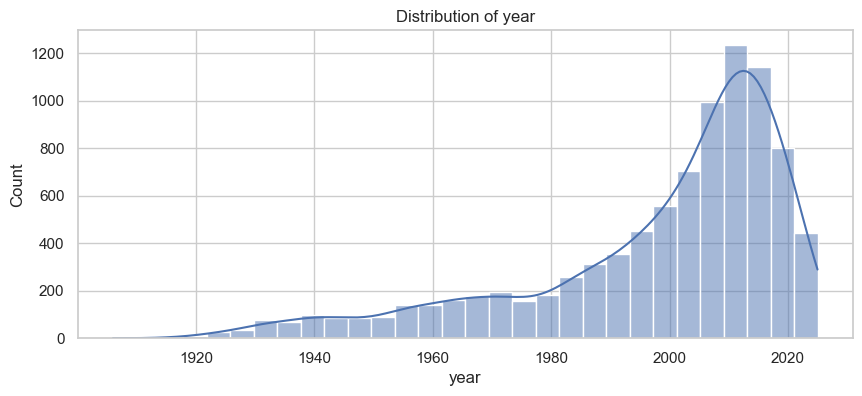

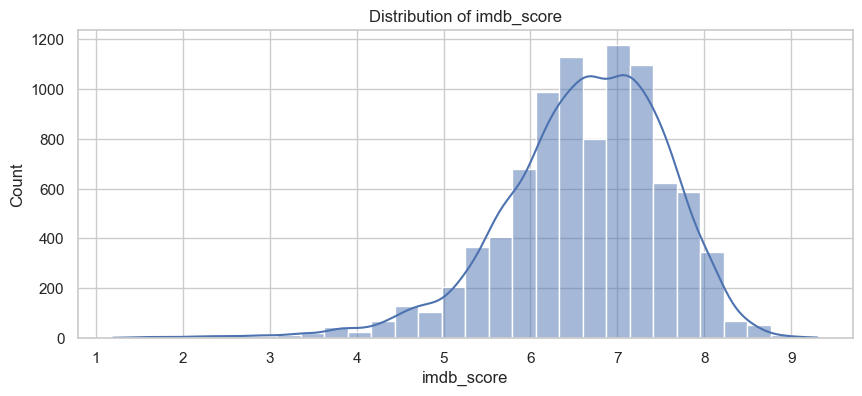

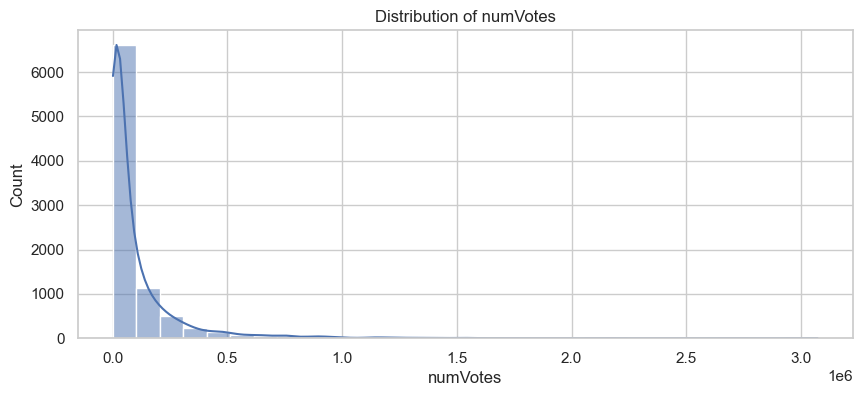

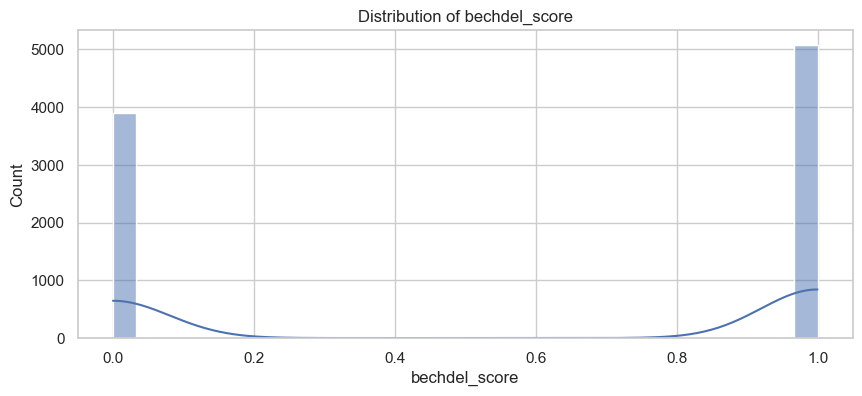

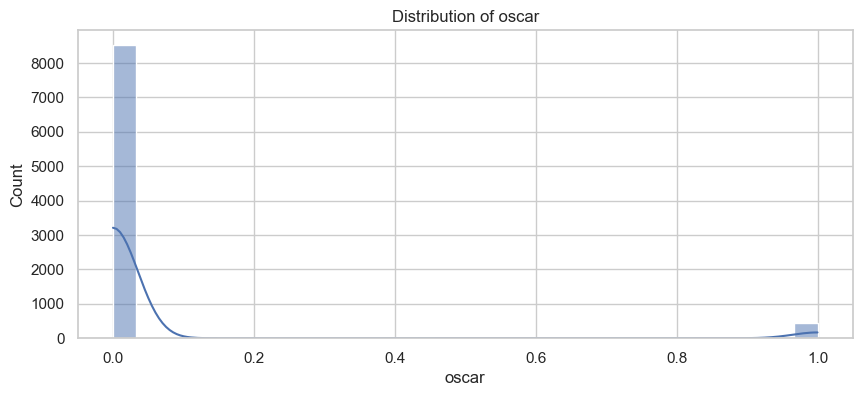

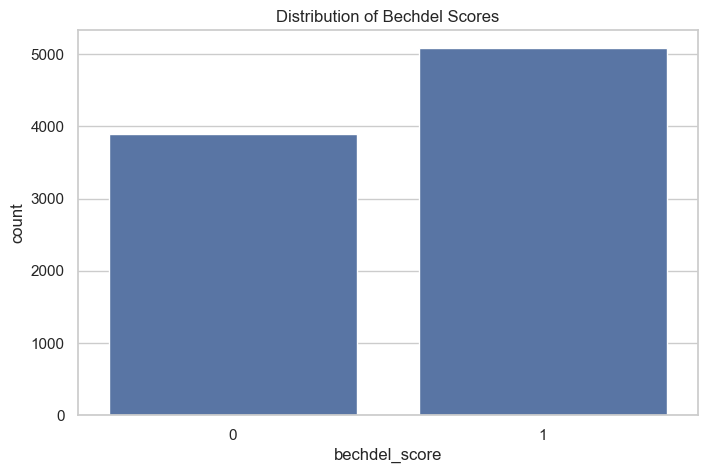

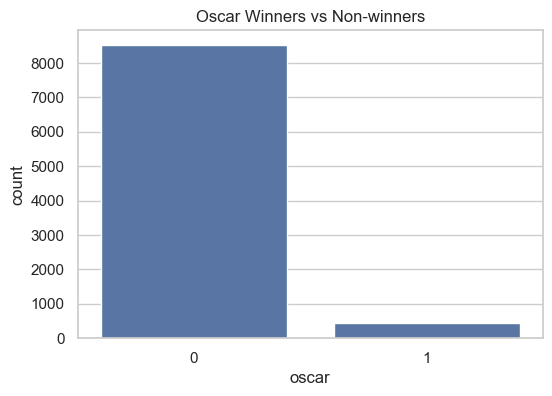

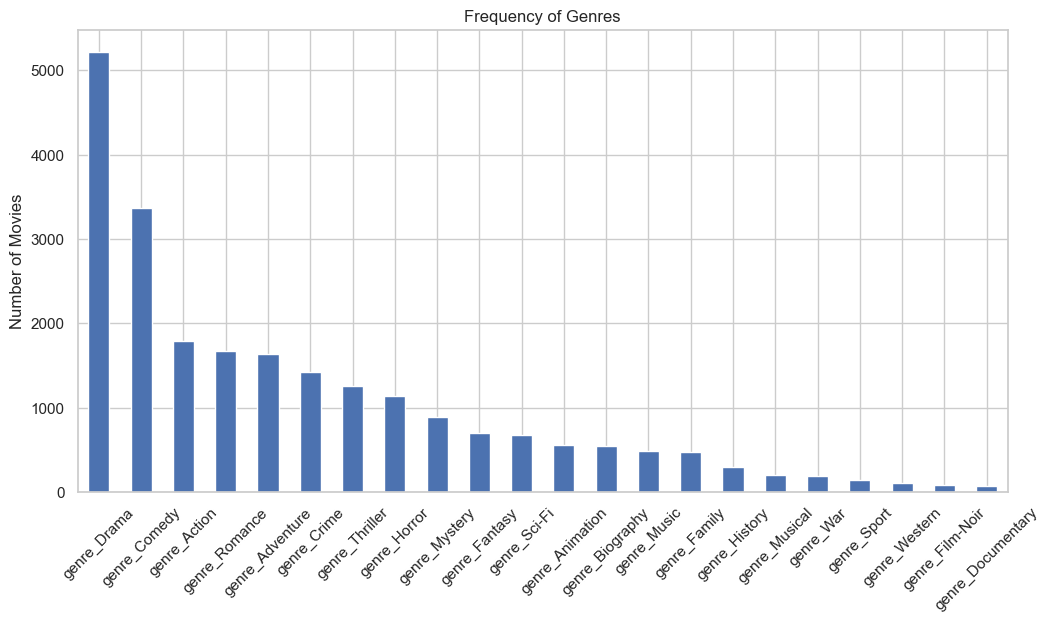

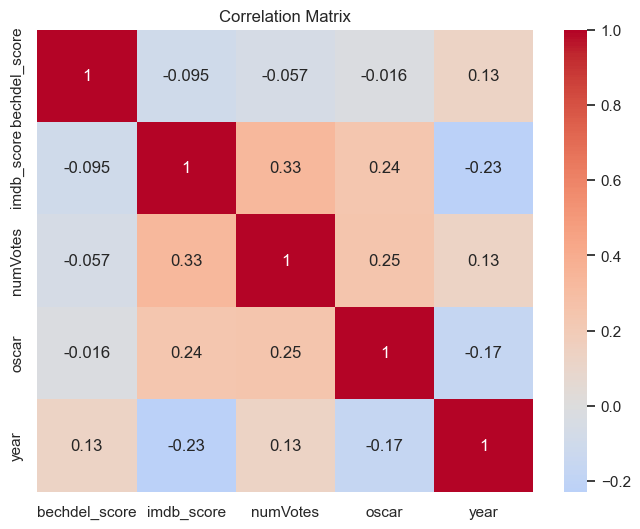

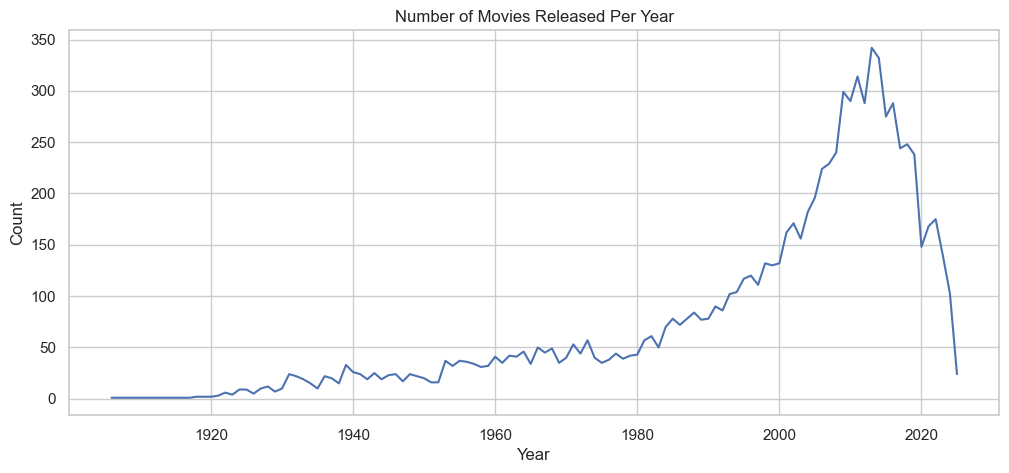

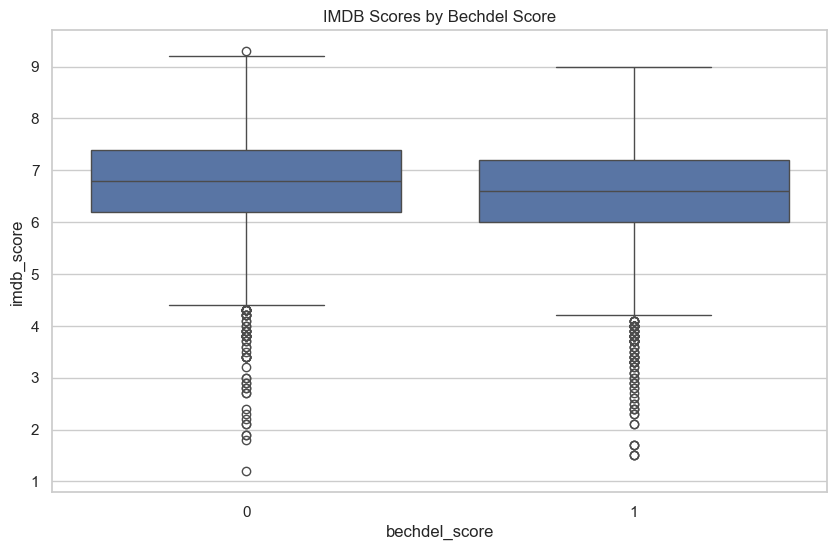

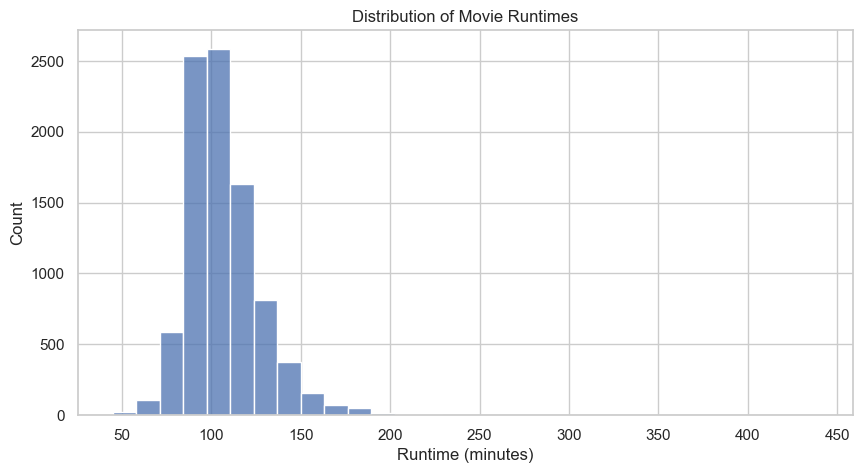


Top 10 Genre Pairs:
Comedy & Drama: 1399 movies
Drama & Romance: 1226 movies
Crime & Drama: 866 movies
Comedy & Romance: 855 movies
Action & Adventure: 785 movies
Adventure & Comedy: 598 movies
Drama & Thriller: 546 movies
Action & Drama: 500 movies
Drama & Mystery: 496 movies
Biography & Drama: 482 movies


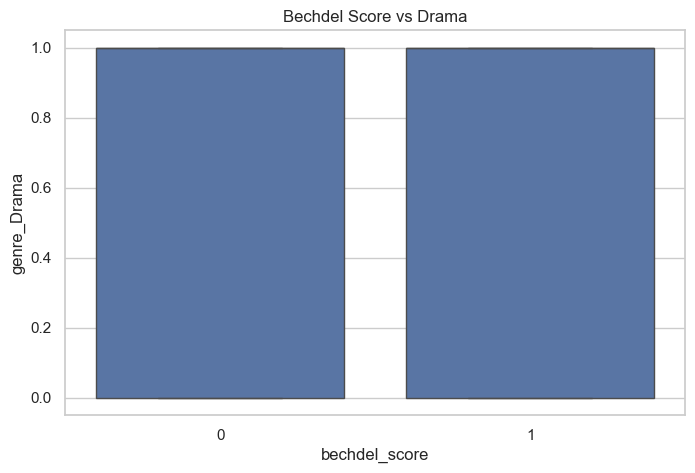

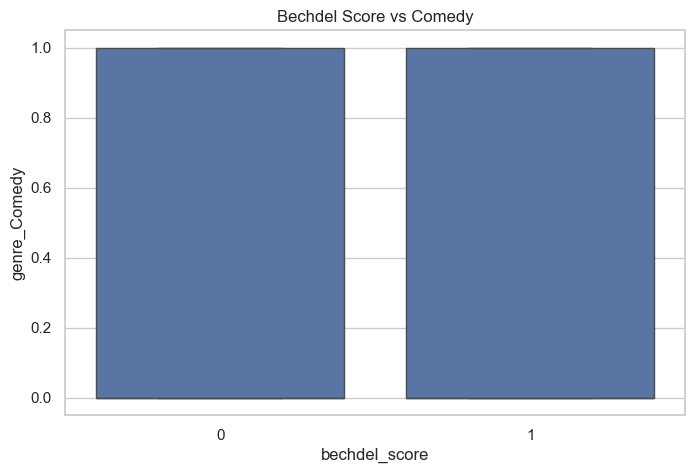

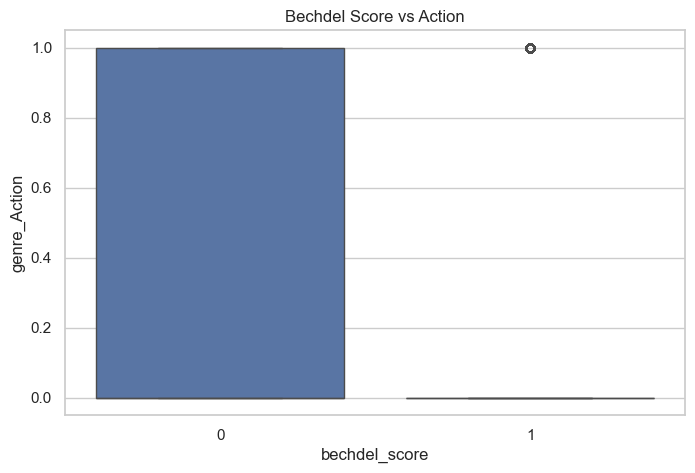

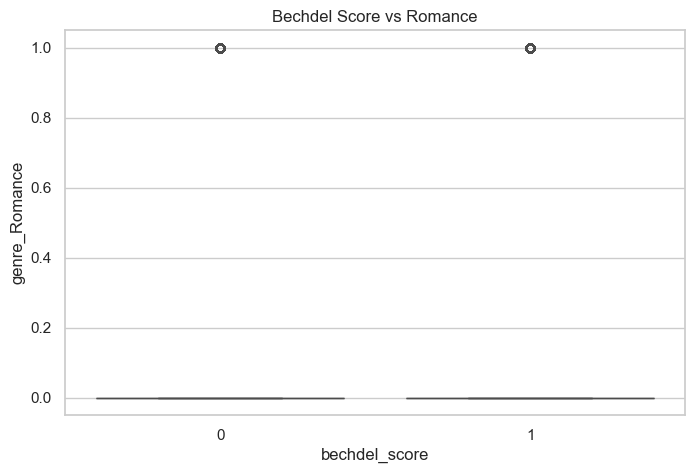

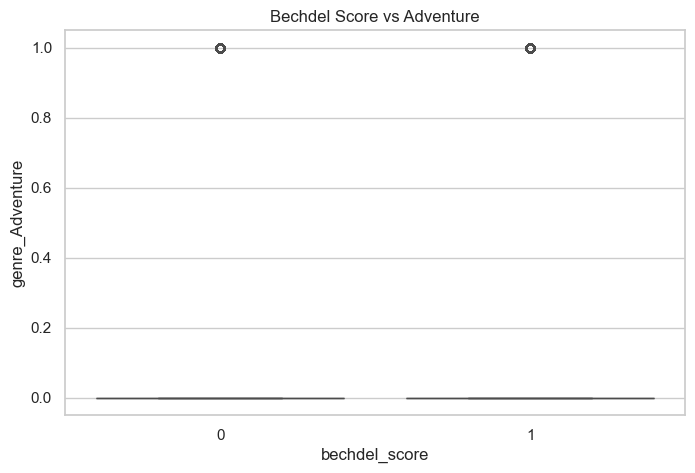

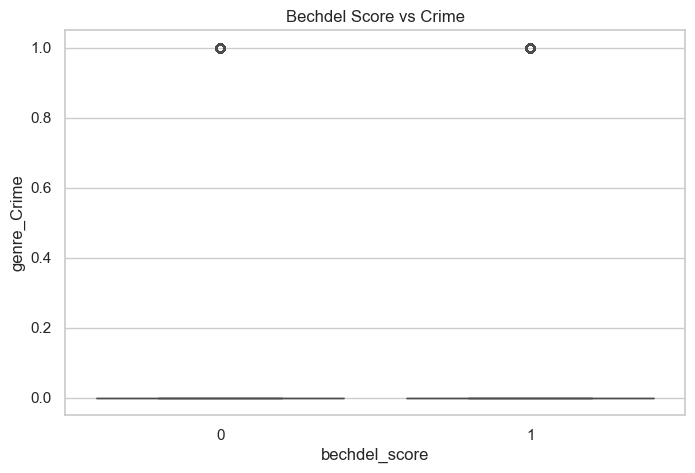

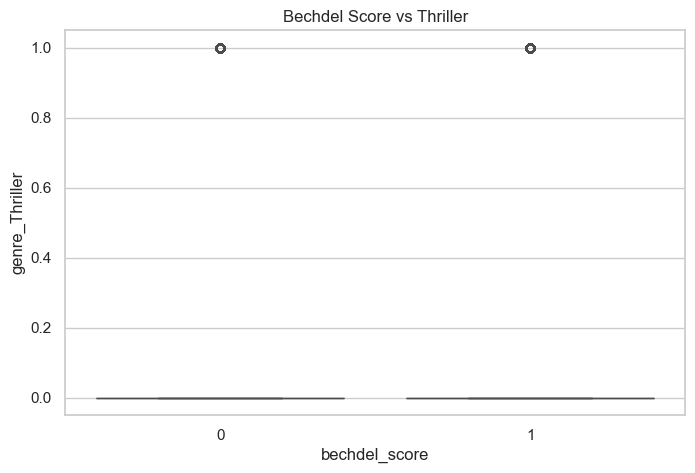

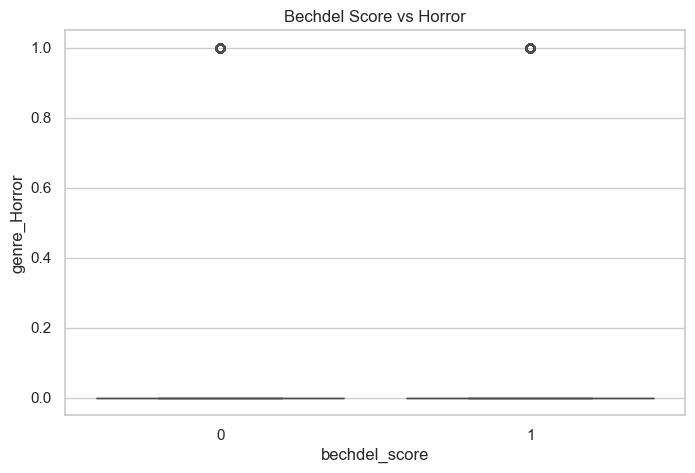

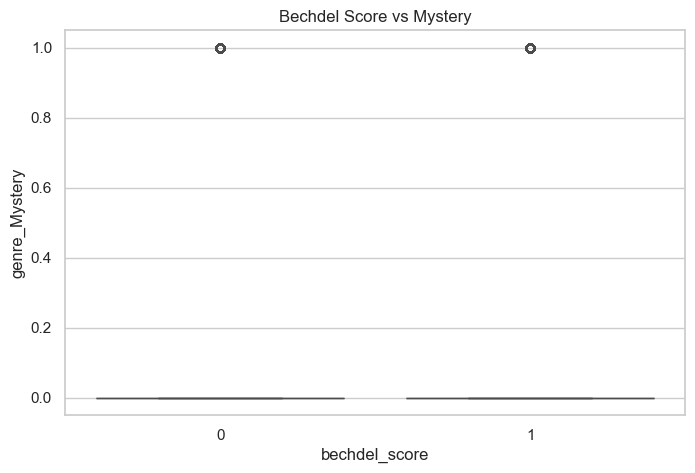

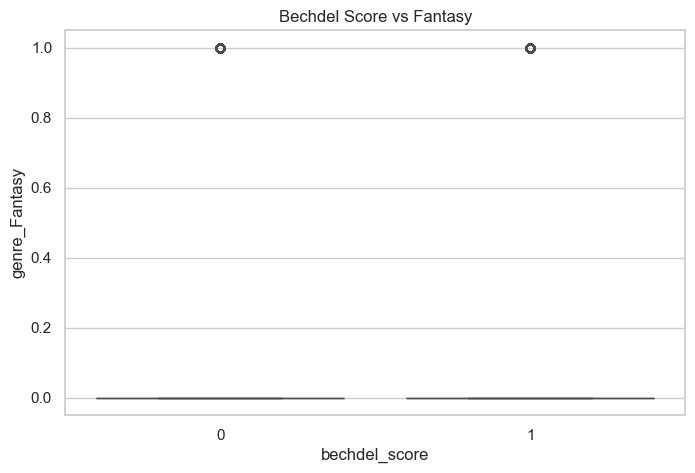

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Basic Statistics
print("=== Basic Statistics ===")
print(df.describe())

# 2. Distribution of Key Numerical Variables
numerical_cols = ['year', 'imdb_score', 'numVotes', 'bechdel_score', 'oscar']
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

# 3. Categorical Analysis
# Bechdel Score distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='bechdel_score', data=df)
plt.title('Distribution of Bechdel Scores')
plt.show()

# Oscar winners vs non-winners
plt.figure(figsize=(6, 4))
sns.countplot(x='oscar', data=df)
plt.title('Oscar Winners vs Non-winners')
plt.show()

# 4. Genre Analysis
# Top genres
genre_cols = [col for col in df.columns if col.startswith('genre_')]
genre_counts = df[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar')
plt.title('Frequency of Genres')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

# 5. Correlation Analysis
# Select numerical columns for correlation
corr_cols = ['bechdel_score', 'imdb_score', 'numVotes', 'oscar', 'year']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# 6. Temporal Analysis
# Movies per year
plt.figure(figsize=(12, 5))
df['year'].value_counts().sort_index().plot()
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

# 7. Bechdel Score vs IMDB Score
plt.figure(figsize=(10, 6))
sns.boxplot(x='bechdel_score', y='imdb_score', data=df)
plt.title('IMDB Scores by Bechdel Score')
plt.show()

# 8. Runtime Analysis (convert to numeric first)
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
plt.figure(figsize=(10, 5))
sns.histplot(df['runtimeMinutes'].dropna(), bins=30)
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.show()

# 9. Genre Combinations
# Most common genre pairs
from itertools import combinations
from collections import Counter

genre_pairs = []
for _, row in df.iterrows():
    movie_genres = [g.replace('genre_', '') for g in genre_cols if row[g] == 1]
    for pair in combinations(movie_genres, 2):
        genre_pairs.append(tuple(sorted(pair)))

top_pairs = Counter(genre_pairs).most_common(10)
print("\nTop 10 Genre Pairs:")
for pair, count in top_pairs:
    print(f"{pair[0]} & {pair[1]}: {count} movies")

# 10. Bechdel Score by Genre
for genre in genre_counts.index[:10]:  # Top 10 genres
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='bechdel_score', y=genre, data=df)
    plt.title(f'Bechdel Score vs {genre.replace("genre_", "")}')
    plt.show()